# Sol — TinyStories EDA

Exploratory analysis of the cleaned, deduped, tokenized TinyStories corpus
produced by `data/prepare.py` / `data/train_tokenizer.py` / `data/tokenize.py`
(M1). Every number here is either read directly from `data/processed/stats.json`
/ `data/tokenized/meta.json`, or computed fresh from the actual written
`.jsonl` / `.bin` files — nothing is hand-typed. `docs/DATA_CARD.md` (M2)
draws its numbers from this notebook's output.


In [1]:
import json
import sys
from pathlib import Path


def _find_project_root(start: Path) -> Path:
    # Jupyter's default kernel cwd is the notebook's own directory (data/),
    # not wherever it was launched from — walk up to the real project root
    # (marked by pyproject.toml) instead of assuming cwd is already correct.
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("could not locate project root (pyproject.toml not found)")


_root = _find_project_root(Path.cwd())
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as spstats
from tokenizers import Tokenizer

from data.eda_utils import (
    char_lengths_from_jsonl,
    chunked_token_frequency,
    coverage_at,
    percentiles,
    token_lengths_from_bin,
)
from src.plot_style import CATEGORICAL, SEQUENTIAL_BLUE, CHROME, savefig, use_style

use_style()

PROCESSED = _root / "data" / "processed"
TOKENIZED = _root / "data" / "tokenized"
FIGURES = _root / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

BLOCK_SIZE = 512  # configs/micro_50m_8gb.yaml model.block_size


## Source stats

Raw numbers from M1, as written by `data/prepare.py` and `data/tokenize.py`.

In [2]:
with (PROCESSED / "stats.json").open() as f:
    stats = json.load(f)
with (TOKENIZED / "meta.json").open() as f:
    meta = json.load(f)

print(json.dumps(stats, indent=2))
print(json.dumps(meta, indent=2))


{
  "dataset": "roneneldan/TinyStories",
  "min_chars": 20,
  "max_chars": 2000,
  "near_dedup_enabled": false,
  "seed": 42,
  "generated_at": "2026-08-04T15:51:58Z",
  "train": {
    "raw_count": 2119719,
    "dropped_too_short": 230,
    "dropped_too_long": 62121,
    "dropped_exact_dup": 309010,
    "dropped_near_dup": 0,
    "dropped_cross_split_leakage": 0,
    "kept": 1748358,
    "char_count_kept": 1478225283,
    "exact_dup_rate": 0.1458
  },
  "validation": {
    "raw_count": 21990,
    "dropped_too_short": 0,
    "dropped_too_long": 545,
    "dropped_exact_dup": 0,
    "dropped_near_dup": 0,
    "dropped_cross_split_leakage": 6304,
    "kept": 15141,
    "char_count_kept": 12308857,
    "exact_dup_rate": 0.0
  },
  "notes": "Uses TinyStories' native train/validation split rather than a custom val_split carve-out (see docs/PROJECT.md 'Resolved decisions'). config.data.val_split is informational only for this dataset."
}
{
  "vocab_size": 32000,
  "dtype": "uint16",
  "eot_id"

## Dedup funnel

Where documents went, train split: raw -> length filter -> exact dedup -> kept.
Ordinal sequential ramp (single hue, light->dark) per the dataviz palette —
this is exactly the "funnel stages" case the ramp's ordinal mode is
documented for.


saved C:\Users\manol\Projects\sol\docs\figures\dedup_funnel.png (167 dpi, ~1503px wide)


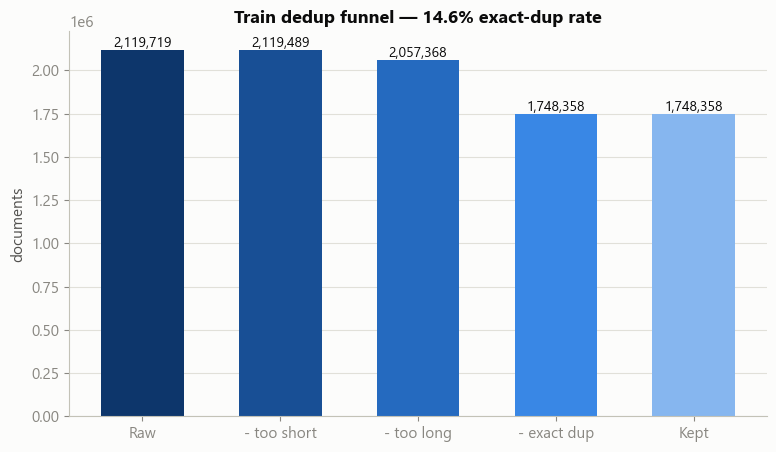

In [3]:
train = stats["train"]
funnel_labels = ["Raw", "- too short", "- too long", "- exact dup", "Kept"]
funnel_values = [
    train["raw_count"],
    train["raw_count"] - train["dropped_too_short"],
    train["raw_count"] - train["dropped_too_short"] - train["dropped_too_long"],
    train["raw_count"] - train["dropped_too_short"] - train["dropped_too_long"] - train["dropped_exact_dup"],
    train["kept"],
]
assert funnel_values[-1] == train["kept"]

ramp_steps = [700, 600, 500, 400, 250]  # dark -> light, ordinal, light-surface floor is step 250
colors = [SEQUENTIAL_BLUE[s] for s in ramp_steps]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(funnel_labels, funnel_values, color=colors, width=0.6)
for bar, val in zip(bars, funnel_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:,}",
            ha="center", va="bottom", fontsize=10, color=CHROME["primary_ink"])
ax.set_ylabel("documents")
ax.set_title(f"Train dedup funnel — {train['exact_dup_rate']:.1%} exact-dup rate")
ax.grid(axis="x", visible=False)
savefig(fig, FIGURES / "dedup_funnel.png")
plt.show()


## Document length distribution

Both character length (from the cleaned `.jsonl`) and token length (recovered
exactly from `.bin` document boundaries — no re-tokenization needed) for train
and validation. The token-length p90/p99 is what actually justifies
`block_size=512` in the model config: it's set from measurement here, not a
guess.


In [4]:
train_char_len = char_lengths_from_jsonl(PROCESSED / "train.jsonl")
val_char_len = char_lengths_from_jsonl(PROCESSED / "val.jsonl")

train_tok_len = token_lengths_from_bin(TOKENIZED / "train.bin", eot_id=meta["eot_id"])
val_tok_len = token_lengths_from_bin(TOKENIZED / "val.bin", eot_id=meta["eot_id"])

assert len(train_tok_len) == meta["splits"]["train"]["doc_count"]
assert len(val_tok_len) == meta["splits"]["val"]["doc_count"]
assert train_tok_len.sum() + len(train_tok_len) == meta["splits"]["train"]["token_count"]  # + 1 EOT/doc

char_p = percentiles(train_char_len)
tok_p = percentiles(train_tok_len)
coverage_512 = coverage_at(train_tok_len, BLOCK_SIZE)

print(f"train char length  p50={char_p[50]:.0f}  p90={char_p[90]:.0f}  p99={char_p[99]:.0f}")
print(f"train token length p50={tok_p[50]:.0f}  p90={tok_p[90]:.0f}  p99={tok_p[99]:.0f}")
print(f"coverage at block_size={BLOCK_SIZE}: {coverage_512:.2%} of train stories fit whole")


train char length  p50=778  p90=1210  p99=1863
train token length p50=184  p90=298  p99=479
coverage at block_size=512: 99.74% of train stories fit whole


saved C:\Users\manol\Projects\sol\docs\figures\length_dist.png (150 dpi, ~1950px wide)


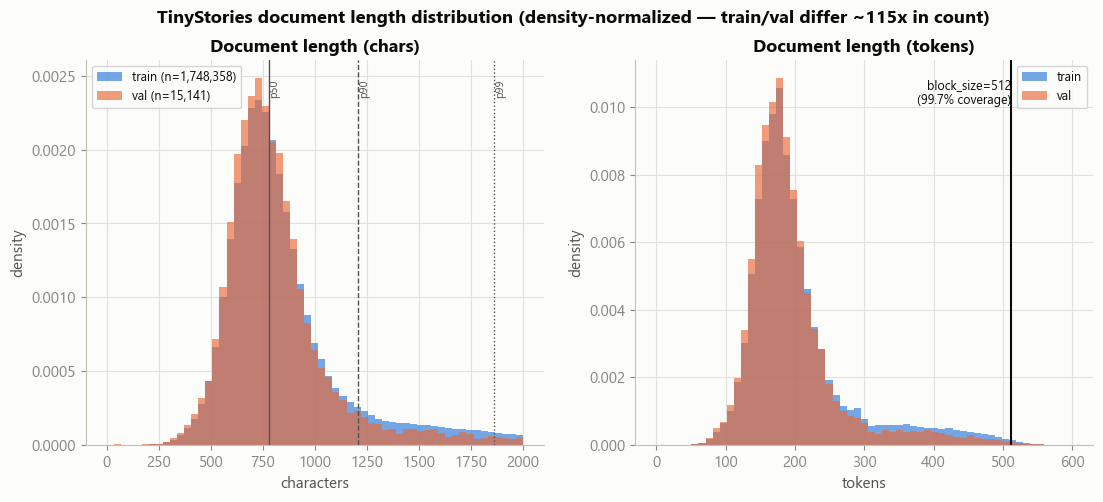

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# density=True throughout: val is <1% the size of train by document count, so
# overlaying raw counts would render val as a flat line at this scale. The
# comparison that actually matters (and what the KS test below is really
# checking) is distribution *shape*, which density normalization shows
# regardless of the sample-size gap.

ax = axes[0]
bins = np.linspace(0, 2000, 60)
ax.hist(train_char_len, bins=bins, density=True, alpha=0.65, color=CATEGORICAL[0], label=f"train (n={len(train_char_len):,})")
ax.hist(val_char_len, bins=bins, density=True, alpha=0.65, color=CATEGORICAL[1], label=f"val (n={len(val_char_len):,})")
for p, style in zip((50, 90, 99), ("-", "--", ":")):
    ax.axvline(char_p[p], color=CHROME["secondary_ink"], linestyle=style, linewidth=1)
    ax.text(char_p[p], ax.get_ylim()[1] * 0.95, f"p{p}", rotation=90, fontsize=8, va="top", color=CHROME["secondary_ink"])
ax.set_xlabel("characters"); ax.set_ylabel("density"); ax.set_title("Document length (chars)"); ax.legend(fontsize=9)

ax = axes[1]
bins = np.linspace(0, 600, 60)
ax.hist(train_tok_len, bins=bins, density=True, alpha=0.65, color=CATEGORICAL[0], label="train")
ax.hist(val_tok_len, bins=bins, density=True, alpha=0.65, color=CATEGORICAL[1], label="val")
ax.axvline(BLOCK_SIZE, color=CHROME["primary_ink"], linestyle="-", linewidth=1.5)
ax.text(BLOCK_SIZE, ax.get_ylim()[1] * 0.95, f"block_size={BLOCK_SIZE}\n({coverage_512:.1%} coverage)",
        fontsize=9, va="top", ha="right", color=CHROME["primary_ink"])
ax.set_xlabel("tokens"); ax.set_ylabel("density"); ax.set_title("Document length (tokens)"); ax.legend(fontsize=9)

fig.suptitle("TinyStories document length distribution (density-normalized — train/val differ ~115x in count)", fontweight="bold")
savefig(fig, FIGURES / "length_dist.png")
plt.show()


## Token frequency & Zipf's law

Full-corpus frequency of every BPE token id (chunked bincount over
`train.bin` — no re-tokenization). A healthy BPE vocabulary should show
roughly Zipfian decay (rank-frequency slope near -1 in log-log); a flat or
very steep slope would suggest an under- or over-merged vocabulary.


In [6]:
freq = chunked_token_frequency(TOKENIZED / "train.bin", vocab_size=meta["vocab_size"])
tokenizer = Tokenizer.from_file(str(_root / "data" / "tokenizer" / "tokenizer.json"))

unk_rate = freq[meta["unk_id"]] / freq.sum()
print(f"UNK rate: {unk_rate:.6%}  ({freq[meta['unk_id']]:,} / {freq.sum():,} tokens)")

order = np.argsort(freq)[::-1]
ranks = np.arange(1, len(order) + 1)
sorted_freq = freq[order]

top50_ids = order[:50]
top50_labels = [tokenizer.id_to_token(int(i)) for i in top50_ids]
print("top 10 tokens:", top50_labels[:10])


UNK rate: 0.000000%  (0 / 357,852,786 tokens)
top 10 tokens: ['.', 'Ġand', ',', 'Ġthe', 'Ċ', 'Ġto', 'Ġa', 'Ġwas', 'Ġit', 'Ġher']


saved C:\Users\manol\Projects\sol\docs\figures\zipf.png (188 dpi, ~1504px wide)


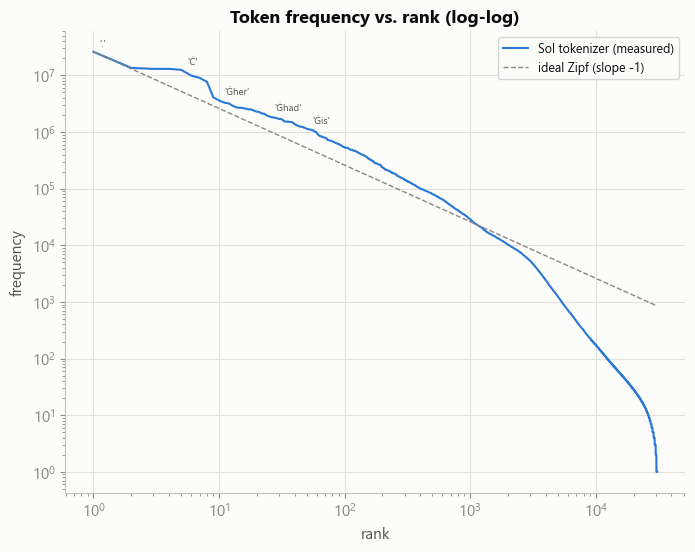

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
nonzero = sorted_freq > 0
ax.loglog(ranks[nonzero], sorted_freq[nonzero], color=CATEGORICAL[0], linewidth=1.5, label="Sol tokenizer (measured)")

# Reference Zipf slope -1, anchored at rank 1's frequency, for visual comparison.
ref = sorted_freq[0] / ranks[nonzero]
ax.loglog(ranks[nonzero], ref, color=CHROME["muted"], linestyle="--", linewidth=1, label="ideal Zipf (slope -1)")

for i in (0, 4, 9, 24, 49):
    ax.annotate(repr(top50_labels[i]), (ranks[i], sorted_freq[i]),
                fontsize=7, color=CHROME["secondary_ink"],
                xytext=(4, 4), textcoords="offset points")

ax.set_xlabel("rank"); ax.set_ylabel("frequency"); ax.legend(fontsize=9)
ax.set_title("Token frequency vs. rank (log-log)")
savefig(fig, FIGURES / "zipf.png")
plt.show()


## Train / validation distribution comparison

A two-sample Kolmogorov-Smirnov test on document length — if train and val
come from different length distributions, val perplexity comparisons across
checkpoints get harder to trust cleanly.


In [8]:
ks_char = spstats.ks_2samp(train_char_len, val_char_len)
ks_tok = spstats.ks_2samp(train_tok_len, val_tok_len)
print(f"char length KS: statistic={ks_char.statistic:.4f}  p={ks_char.pvalue:.4g}")
print(f"token length KS: statistic={ks_tok.statistic:.4f}  p={ks_tok.pvalue:.4g}")
print()
print("A small KS statistic (close to 0) means the two distributions are close" \
      " regardless of the p-value's significance at this sample size" \
      " (n in the tens of thousands makes even small gaps 'significant').")


char length KS: statistic=0.0434  p=4.616e-25
token length KS: statistic=0.0466  p=9.086e-29

A small KS statistic (close to 0) means the two distributions are close regardless of the p-value's significance at this sample size (n in the tens of thousands makes even small gaps 'significant').


## Compression ratio (chars per token)

Not saved as a standalone figure — a quick sanity check that the tokenizer's
compression is in a sane range for English prose (typically ~4 chars/token).


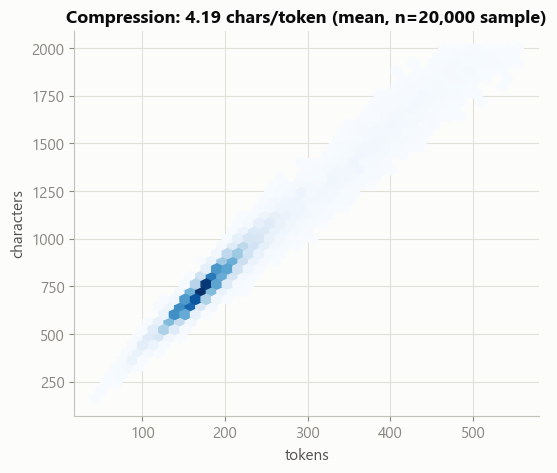

mean chars/token: 4.189
median chars/token: 4.203


In [9]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(train_char_len), size=min(20_000, len(train_char_len)), replace=False)
chars_per_token = train_char_len[sample_idx] / np.maximum(train_tok_len[sample_idx], 1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hexbin(train_tok_len[sample_idx], train_char_len[sample_idx], gridsize=40, cmap="Blues", mincnt=1)
ax.set_xlabel("tokens"); ax.set_ylabel("characters")
ax.set_title(f"Compression: {chars_per_token.mean():.2f} chars/token (mean, n={len(sample_idx):,} sample)")
plt.show()

print(f"mean chars/token: {chars_per_token.mean():.3f}")
print(f"median chars/token: {np.median(chars_per_token):.3f}")


## Summary — numbers for docs/DATA_CARD.md

Every value `docs/DATA_CARD.md` cites is printed by the cell below — copied
from there, not retyped from memory, so the data card can't silently drift
from what this notebook actually measured.


In [10]:
print(f"train_kept={stats['train']['kept']:,}")
print(f"val_kept={stats['validation']['kept']:,}")
print(f"train_tok={meta['splits']['train']['token_count']:,}")
print(f"val_tok={meta['splits']['val']['token_count']:,}")
print(f"train_dup={stats['train']['exact_dup_rate']:.4f}")
print(f"val_dup={stats['validation']['exact_dup_rate']:.4f}")
print(f"unk_rate={unk_rate:.6f}")
print(f"chars_per_token_mean={chars_per_token.mean():.3f}")
print(f"char_p50={char_p[50]:.0f} char_p90={char_p[90]:.0f} char_p99={char_p[99]:.0f}")
print(f"tok_p50={tok_p[50]:.0f} tok_p90={tok_p[90]:.0f} tok_p99={tok_p[99]:.0f}")
print(f"coverage_at_512={coverage_512:.4f}")


train_kept=1,748,358
val_kept=15,141
train_tok=357,852,786
val_tok=2,956,183
train_dup=0.1458
val_dup=0.0000
unk_rate=0.000000
chars_per_token_mean=4.189
char_p50=778 char_p90=1210 char_p99=1863
tok_p50=184 tok_p90=298 tok_p99=479
coverage_at_512=0.9974
